<a href="https://colab.research.google.com/github/antipetajyothsna-dev/website-traffic-sources-project/blob/main/website_traffic_sources_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1200, 7)

First 5 Rows:
         Date  Traffic Source  Visitors  Sessions  Page Views  \
0  01-01-2024          Direct       960       856        3286   
1  02-01-2024          Direct      3544      3900       14134   
2  03-01-2024        Referral      2533      2256        4625   
3  04-01-2024  Organic Search      3004      2840        9472   
4  05-01-2024        Paid Ads      1906      1959        7552   

   Bounce Rate (%)  Conversions  
0            55.81           11  
1            21.24            2  
2            38.25           22  
3            28.37           28  
4            31.98            3  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             1200 non-null   object 
 1   Traffic Source   1200 non-null   object 
 2   Visitors         1200 non-null   int64  
 3   Sessions 

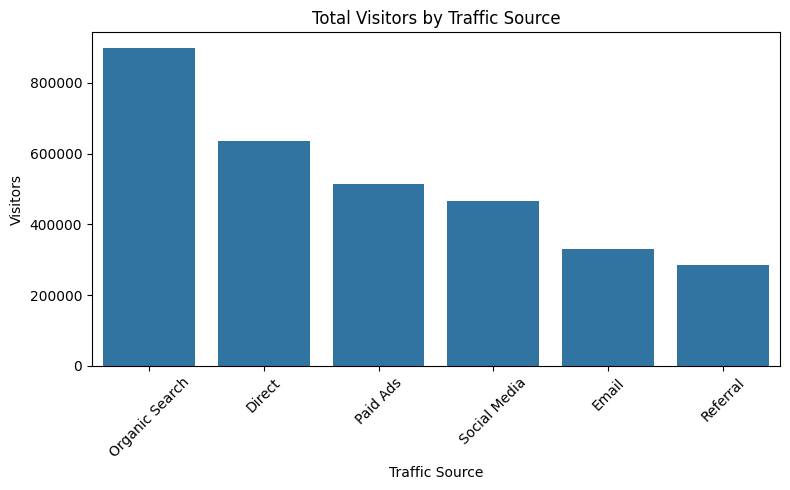

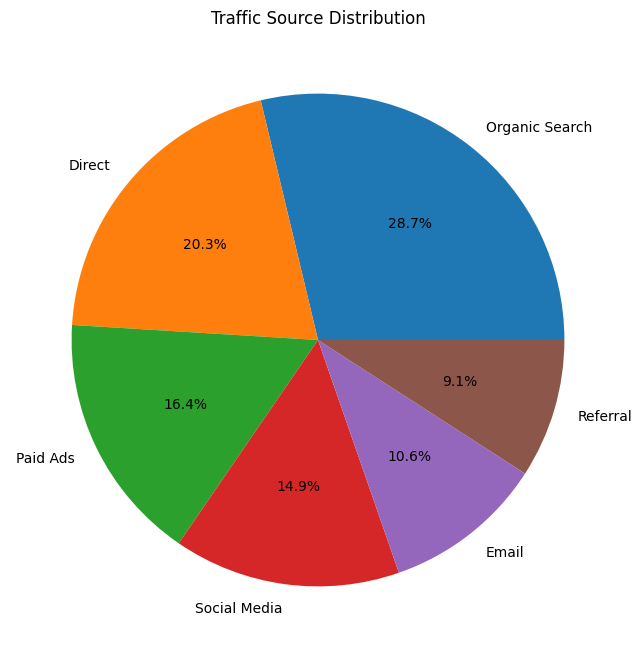

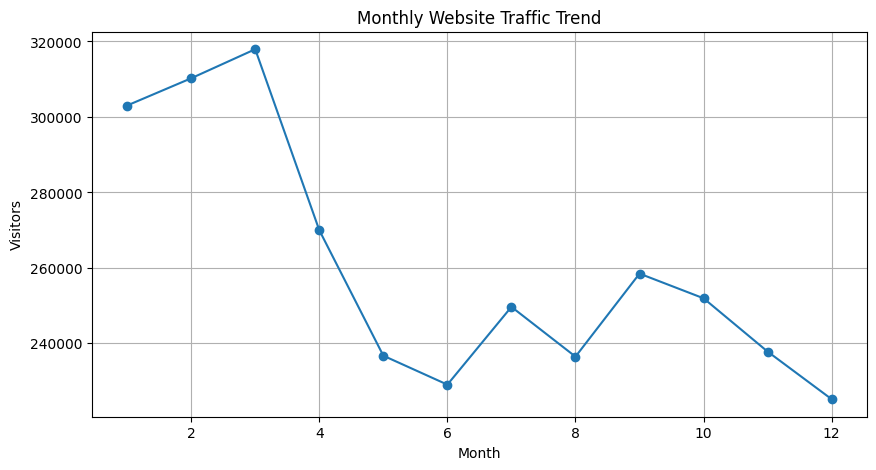

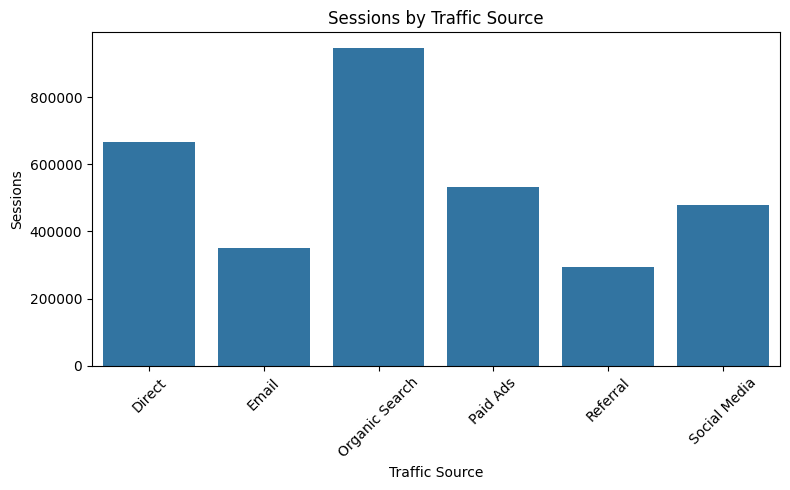

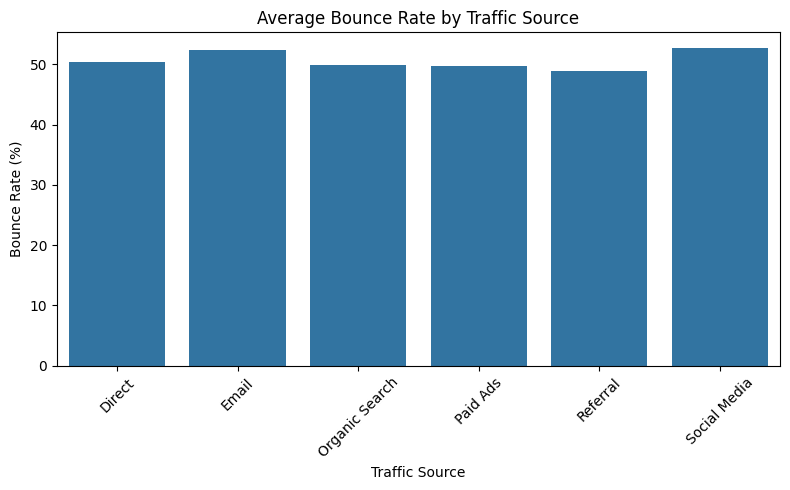

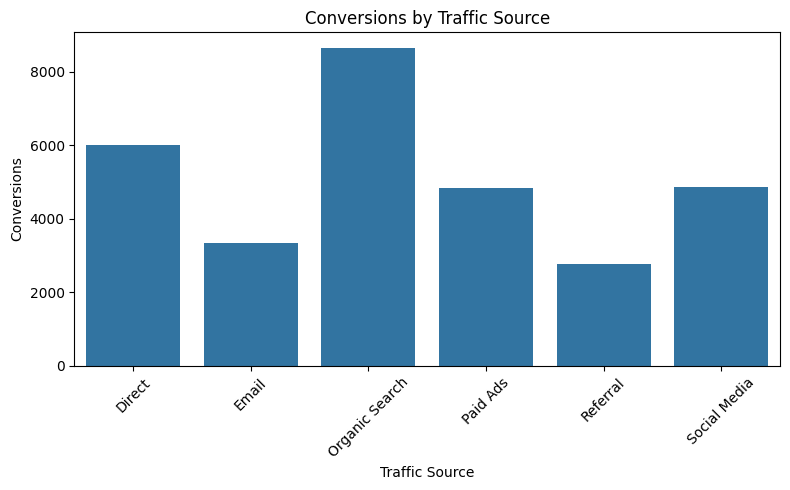


Top Traffic Sources:
Traffic Source
Organic Search    898383
Direct            634417
Paid Ads          513187
Social Media      465342
Email             330028
Referral          285114
Name: Visitors, dtype: int64

Average Bounce Rate:
Traffic Source
Direct            50.333750
Email             52.441308
Organic Search    49.856610
Paid Ads          49.669128
Referral          48.938534
Social Media      52.656185
Name: Bounce Rate (%), dtype: float64

Total Conversions:
Traffic Source
Direct            6008
Email             3344
Organic Search    8641
Paid Ads          4843
Referral          2764
Social Media      4860
Name: Conversions, dtype: int64

Analysis Completed Successfully!
Report saved as 'traffic_analysis_report.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("website_traffic_dataset.csv")

# Display Basic Information
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# -------------------------------
# 1. Total Visitors by Traffic Source
# -------------------------------
traffic_source = df.groupby('Traffic Source')['Visitors'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=traffic_source.index, y=traffic_source.values)
plt.title("Total Visitors by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Visitors")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 2. Traffic Source Distribution
# -------------------------------
plt.figure(figsize=(8,8))
plt.pie(
    traffic_source.values,
    labels=traffic_source.index,
    autopct='%1.1f%%'
)
plt.title("Traffic Source Distribution")
plt.show()

# -------------------------------
# 3. Monthly Traffic Trend
# -------------------------------
monthly_visitors = df.groupby(df['Date'].dt.month)['Visitors'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_visitors.index, monthly_visitors.values, marker='o')
plt.title("Monthly Website Traffic Trend")
plt.xlabel("Month")
plt.ylabel("Visitors")
plt.grid(True)
plt.show()

# -------------------------------
# 4. Sessions by Traffic Source
# -------------------------------
sessions = df.groupby('Traffic Source')['Sessions'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=sessions.index, y=sessions.values)
plt.title("Sessions by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Average Bounce Rate
# -------------------------------
bounce = df.groupby('Traffic Source')['Bounce Rate (%)'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=bounce.index, y=bounce.values)
plt.title("Average Bounce Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Bounce Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 6. Conversions by Traffic Source
# -------------------------------
conversions = df.groupby('Traffic Source')['Conversions'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=conversions.index, y=conversions.values)
plt.title("Conversions by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Conversions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 7. Top Traffic Sources
# -------------------------------
print("\nTop Traffic Sources:")
print(traffic_source)

print("\nAverage Bounce Rate:")
print(bounce)

print("\nTotal Conversions:")
print(conversions)

# -------------------------------
# 8. Save Summary Report
# -------------------------------
summary = pd.DataFrame({
    'Visitors': traffic_source,
    'Sessions': sessions,
    'Avg Bounce Rate': bounce,
    'Conversions': conversions
})

summary.to_csv("traffic_analysis_report.csv")

print("\nAnalysis Completed Successfully!")
print("Report saved as 'traffic_analysis_report.csv'")